# My Notes

- **Course**: Qubits, entanglement and matrix product sates
- **Author**: Théo HUET
- **Date**: 30/01/2026 - 18/02/2026

# TD2 - Matrix Product State

## Exercice 3 : SVD truncation / MPS intution



In [75]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import constants
from utils import *

In [76]:
N = 200

A = random_complexe_matrix(N,N) # random matrix de taille NxN
A = normalisation(A) # normalisation de la matrice

print("||A||² =", norm2(A).round(2))
print("Trace(AA^{dagger}) =", trace(A @ np.transpose(np.conjugate(A))).real)

||A||² = 1.0
Trace(AA^{dagger}) = 0.9999999999999998


We have indeed generated a complex matrix $A$ that represents a normalized state because $||A||^2 = 1$.

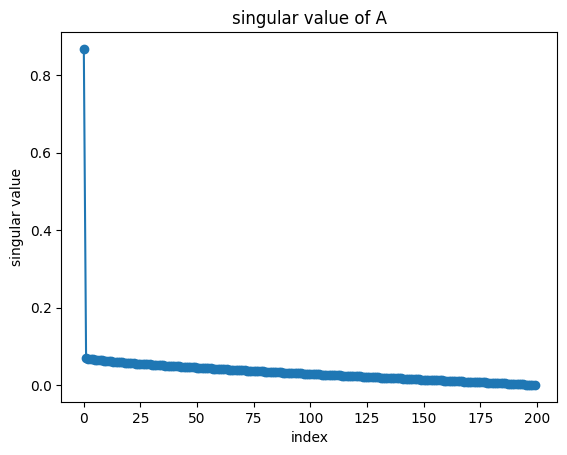

sum singular_value² = 1.0


In [77]:
U, s, Vh = svd(A)

# note : s = si = scipy.linalg.svdvals(A) # calcul les singular value

plt.figure()
plt.plot(s, 'o-')
plt.title("singular value of A")
plt.xlabel("index")
plt.ylabel("singular value")
plt.show()

print("sum singular_value² =", np.sum(s**2).round(2))

We can clearly see that the singular values of our matrix $A$ decrease very quickly to $0$.

We will therefore set a “threshold”: $ds = 0.01$ such that any singular value below this threshold will be removed.

We just need to check whether you are keeping your: $\Sigma_{i}s_i^2 = 1$ which means that the state represented is indeed normalized.

Because the $s_i$ are exactly the Schmidt coefficients, so $s_i^2$ are the eigenvalues of the density matrix and $tr(\rho)=\Sigma_i \lambda_i = 1$ by definition.

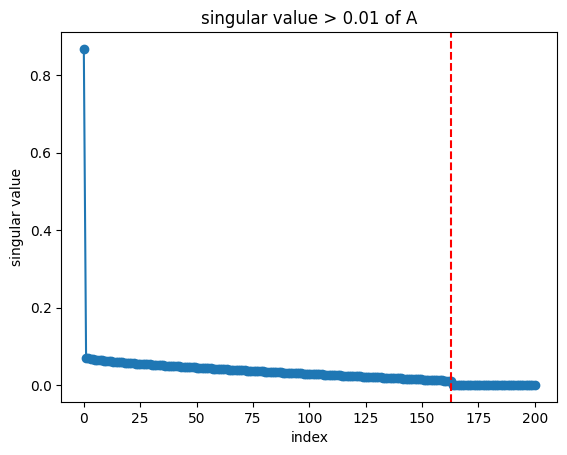

sum singular_value > 0.01)² = 1.0


In [78]:
ds = 0.01

sp = s * (s>ds) # on garde seulement les si > 0.01 on met a 0 les autres

i = np.argmin(sp) # pour savoir ou l'on retire des singular values graphiquement
x = np.linspace(0,N,N)

plt.figure()
plt.plot(x, sp, 'o-')
plt.axvline(x=i,color='red',linestyle='--')
plt.title(f"singular value > {ds} of A")
plt.xlabel("index")
plt.ylabel("singular value")
plt.show()
print(f"sum singular_value > {ds})² =", np.sum(sp**2).round(2))

We can see that even if we remove the values below our ‘threshold’ (to the right of the red line), this changes very little in terms of our problem, because we still have: $\Sigma_{s_i>0.1}s_i^2 \approx 1$.

In [79]:
Ap = dot((U * sp), Vh)

print("||A - Ap||/N =", (np.sqrt(norm2(A - Ap))/N).round(5), "<", ds)
print("||A - Ap||² =", (norm2(A - Ap)).round(5), f"= sum (singular_value > {ds})² =", (np.sum((s * (s<ds))**2)).round(5))

||A - Ap||/N = 0.00018 < 0.01
||A - Ap||² = 0.00131 = sum (singular_value > 0.01)² = 0.00131


The method is very stable, we have $\frac{||A-A'||}{N} < 0.01$.

Here $\frac{||A-A'||}{N} \approx 0.0002$.

And we have $||A-A'||^2 \approx \Sigma_{s_i<0.1}s_i^2$.

This shows us that our change does not alter the state, but greatly simplifies it. We will use this later.

---

## Exercice 4 : 2-Qubit Heisenberg ground state as an MPS

The anti-ferromagnetic Hamiltonian of Two Qubits :
$H = J(\sigma_1^x \sigma_2^x + \sigma_1^y \sigma_2^y + \sigma_1^z \sigma_2^z) = J \vec\sigma_1.\vec\sigma_2 \quad$ and $\quad J = 1$

In [80]:
def compute_H(J : float, nbr_qubit : int) -> np.ndarray:
  assert nbr_qubit in [2, 3]
  if nbr_qubit == 2 :
    return J*(np.kron(constants.X, constants.X) + np.kron(constants.Y, constants.Y) + np.kron(constants.Z, constants.Z))
  elif nbr_qubit == 3 :
    return J*(np.kron(np.kron(constants.X, constants.X),constants.I) + np.kron(np.kron(constants.Y, constants.Y),constants.I) + np.kron(np.kron(constants.Z, constants.Z),constants.I)) + J*(np.kron(np.kron(constants.I, constants.X),constants.X) + np.kron(np.kron(constants.I, constants.Y),constants.Y) + np.kron(np.kron(constants.I, constants.Z),constants.Z))

In [81]:
J = 1.
nbr_qubit = 2

H = compute_H(J, nbr_qubit)

E0, v0 = ground_state(H)

print("E0 =", E0)
print("v0 = ", v0.real.round(3), "\nwith 1/sqrt(2) =", (1/np.sqrt(2)).round(3))

E0 = -3.0
v0 =  [ 0.     0.707 -0.707  0.   ] 
with 1/sqrt(2) = 0.707


Ground state :

$E_0 = -3\quad$ and $\quad v_0 = \frac{|01> -|10>}{\sqrt2}$.

Because $v_0 = (0 \quad \frac{1}{\sqrt2} \quad -\frac{1}{\sqrt2} \quad 0) $ in the base $|00>, |01>, |10>, |11>$.

In [82]:
vM = v0.reshape((2,2))

U, s, Vh = svd(vM)

print("U =\n", U)
print("s =\n", s)
print("Vh =\n", Vh)

U =
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
s =
 [0.70710678 0.70710678]
Vh =
 [[-1.+0.j -0.+0.j]
 [ 0.+0.j  1.+0.j]]


### Output 1

<img src="https://github.com/TheoHUETQC/qubits-entanglement-matrix-product-states/blob/main/td/figure/c_plus_minus.png?raw=1" width="300" alt="MPS à deux sites">

In [83]:
A, B = U, np.diag(s)@Vh

norm = np.einsum('sk,kS,sl,lS->', A.conj(), B.conj(), A, B).real

c = np.einsum('sk,kS,sm,Sn,ml,ln->', A, B, constants.SP,constants.SM, A.conj(), B.conj())

print("Output 1 :")
print("norm =", norm.round(2))
print("c+- =",c.round(2).real, "= -1/2")

Output 1 :
norm = 1.0
c+- = -0.5 = -1/2


The anti-ferromagnetic Hamiltonian of **Three Qubits** :

$H = J \vec\sigma_1.\vec\sigma_2 + J \vec\sigma_2.\vec\sigma_3 \quad$ and $\quad J = 1$

In [84]:
J = 1
nbr_qubit = 3

H = compute_H(J, nbr_qubit)

E0, v0 = ground_state(H)

v_tensor = v0.reshape(2,2,2)
vR = v_tensor.reshape((2,4))

# first SVD
U, s, Vh = svd(vR)

A, BC = U.copy(), np.diag(s) @ Vh
BCr = BC.reshape((4,2))     # BC : (aσ₂, σ₃)

# second SVD
Up, sp, Vhp = svd(BCr)

B = Up.reshape((2,2,2))    # (a, σ₂, b)
C = np.diag(sp) @ Vhp      # (b, σ₃)

In [85]:
print("A :\n", A)
print("B :\n", B)
print("C :\n", C)

norm = np.einsum('sa,akb,bl,is,skj,jl->',
                  A.conj(), B.conj(), C.conj(),
                  A, B, C)                          # verification

print("\nnorm :", norm.real.round(2))

A :
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
B :
 [[[ 0.00000000e+00+0.j  1.00000000e+00+0.j]
  [-8.94427191e-01+0.j  0.00000000e+00+0.j]]

 [[ 4.47213595e-01+0.j  5.55111512e-17+0.j]
  [ 4.96506831e-17+0.j  6.16297582e-33+0.j]]]
C :
 [[-0.91287093+0.j  0.        +0.j]
 [ 0.        +0.j -0.40824829+0.j]]

norm : 1.0


### Output 2

<img src="https://github.com/TheoHUETQC/qubits-entanglement-matrix-product-states/blob/main/td/figure/c_plus_id_minus.png?raw=1" width="400" alt="MPS à trois sites">

In [86]:
c = np.einsum('ia, ajb, bk, iI, kK, Ic, cjd, dK->',
                A, B, C,
                constants.SP,            
                constants.SM, 
                A.conj(), B.conj(), C.conj())

print("c+id- :", c.real)

c+id- : 0.16666666666666677


the theoretical result is  $\approx 0.1666\dots$, so we get the right result.

---

## Exercice 5 : Imaginary-time evolutionfor the 2-site ground state

We use imaginary-time evolution to compute the ground state :
$$ |GS \rangle = \lim_{t \rightarrow \infty }\frac{e^{-tH}|\Psi_0 \rangle}{||e^{-tH}|\Psi_0 \rangle ||} \quad \text{with} \quad |\Psi_0 \rangle = |01 \rangle $$

We know that we have $E_0 = -3$, the theroical result.

In [87]:
state0 = np.array([1, 0], dtype=complex)
state1 = np.array([0, 1], dtype=complex)
psi0 = np.kron(state0, state1)

E_0_theoric = -3

vR = psi0.reshape(2,2)

U, s, Vh = svd(vR)

print("U =\n", U)
print("s =\n", s)
print("Vh =\n", Vh)

U =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
s =
 [1. 0.]
Vh =
 [[ 0.+0.j  1.+0.j]
 [-1.+0.j  0.+0.j]]


A singular value = 0, so we have “bond dimension = 1.”

The hamiltonian in this exercice :
$$ H = XX+YY+ZZ$$

Evolution operator :
$$G = e^{-\delta \tau H} \quad \text{with} \quad \delta \tau = 0.1$$

It's applie to our psi vector like: 

<img src="https://github.com/TheoHUETQC/qubits-entanglement-matrix-product-states/blob/main/td/figure/evolution_psi.png?raw=1" width="300" alt="Evolution de psi avec G">

In [88]:
from scipy.linalg import expm

H = np.kron(constants.X, constants.X) + np.kron(constants.Y, constants.Y) + np.kron(constants.Z,constants.Z)
HR = H.reshape(2,2,2,2)

GR = expm(-constants.dt*HR)

def compute_E(A: np.array, B: np.array, HR: np.array) -> float : # <H>
  return np.einsum('sk,kS,sSlL,lm,mL->', A.conj(), B.conj(), HR, A, B).real

def evolution_psi(A : np.array, B: np.array, GR: np.array) -> np.array :
  psi = np.einsum('ijsS, sk, kS->ij', GR, A, B)
  return psi

def mps(psi: np.array) -> tuple[np.array, np.array]:
  psiR = psi.reshape(2,2) # pas utile.. ici
  U, s, Vh = svd(psiR)
  s /= np.sqrt(np.sum(s**2)) # normalisation car l'évolution n'est pas unitaire
  return U, np.diag(s)@Vh, s

In [89]:
def simulation(Nt : int) :
  E, S = [], []
  psi = psi0.reshape(2,2)
  for i in range(Nt) :
    A, B, s = mps(psi)
    assert np.abs(np.linalg.norm(A@B) - 1) < constants.epsilon # check the norm
    psi = evolution_psi(A, B, GR)

    E.append(compute_E(A, B, HR))
    S.append(measurements_entropy_SVD(s))
  return E, S

### Output :

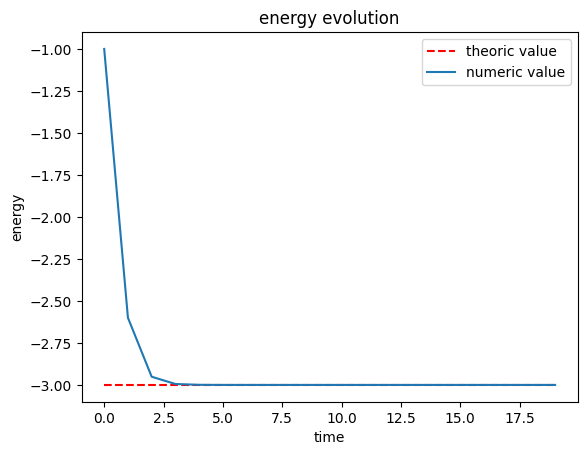

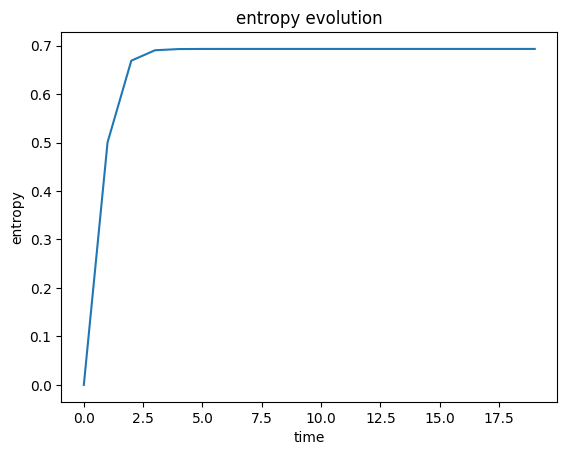

Ground state energy aproximation : -2.999995335899009
error with Theorical result : 4.664100991202957e-06


In [90]:
E, S = simulation(20)
E_0 = E[-1]

plt.figure()
plt.hlines(E_0_theoric, 0, 19, color='red', linestyles='--', label='theoric value')
plt.plot(E, label='numeric value')
plt.title("energy evolution")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.show()

plt.figure()
plt.plot(S, label='numeric value')
plt.title("entropy evolution")
plt.xlabel("time")
plt.ylabel("entropy")
plt.show()

print("Ground state energy aproximation :", E_0)
print("error with Theorical result :", np.abs(E_0 - E_0_theoric))

We find a good approximation of the ground state energy (with an error of the order $10^{-6}$)

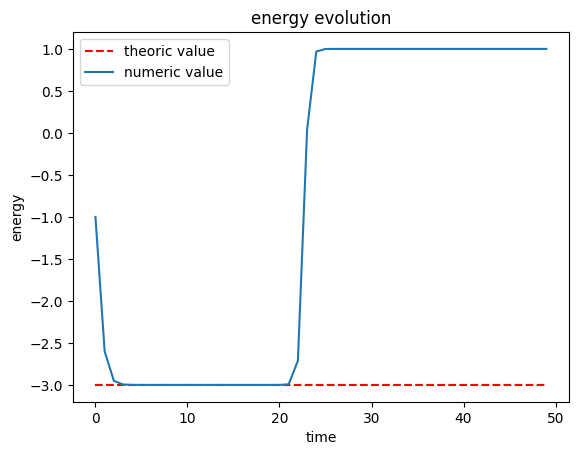

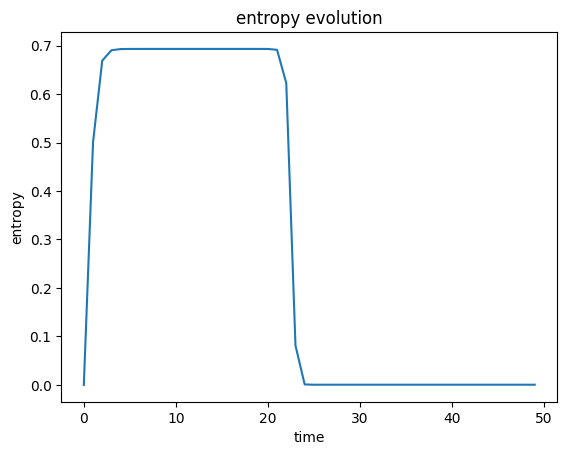

Ground state energy aproximation : 0.9999999999999999
error with Theorical result : 4.0


In [91]:
E, S = simulation(50)
E_0 = E[-1]

plt.figure()
plt.hlines(E_0_theoric, 0, 49, color='red', linestyles='--', label='theoric value')
plt.plot(E, label='numeric value')
plt.title("energy evolution")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.show()

plt.figure()
plt.plot(S, label='numeric value')
plt.title("entropy evolution")
plt.xlabel("time")
plt.ylabel("entropy")
plt.show()

print("Ground state energy aproximation :", E_0)
print("error with Theorical result :", np.abs(E_0 - E_0_theoric))

Beyond approximately 20 step of simulation, the method is no longer stable (the error grows until $4$).

---

## Exercice 6 : iTEBD for the ising chain

$$H = - \Sigma_j (\sigma_j^x\sigma_{j+1}^x + h \sigma_j^z) = \Sigma_j h_{j,j+1}$$

$$h_{j,j+1} = - \sigma_j^x \sigma_{j+1}^x - \frac{h}{2}(\sigma_j^z I_{j+1} + I_j \sigma_{j+1}^z) $$

In [92]:
#init

def gate_ising_two_site(h: float, delta: float): # delta = delta tau
    """
    Build the imaginary-time two-site gate G = exp(-delta * h2)
    with h2 = -sx⊗sx - (h/2)(sz⊗I + I⊗sz).
    Returns:
      G4 : shape (2,2,2,2) with indices (s1', s2', s1, s2)
      h2_4 : same shape for measuring energy <h2>
    """
    h2 = -np.kron(constants.X, constants.X) - 0.5 * h * (np.kron(constants.Z, constants.I) + np.kron(constants.I, constants.Z))  # 4x4 Hermitian
    w, V = np.linalg.eigh(h2)
    G = V @ np.diag(np.exp(-delta * w)) @ V.conj().T                        # 4x4
    G4 = G.reshape(2, 2, 2, 2)                                              # (s1',s2',s1,s2)
    h2_4 = h2.reshape(2, 2, 2, 2)
    return G4, h2_4

# ----------------------------
# Initial iMPS: product of singlets on AB bonds
# ----------------------------
# Unit cell ...-B-A-B-A-...
# We store: GammaA (chiBA,d,chiAB), GammaB (chiAB,d,chiBA)
# with lambdas: lamAB (between A and B), lamBA (between B and A)
def init_singlet_dimer():
    # From your sheet:
    # A_{i σ k} = δ_{i,1} [[1,0],[0,-1]]_{σ,k}
    # B_{k σ l} = [[0,1],[1,0]]_{k,σ} δ_{l,1}
    chiBA, d, chiAB = 1, 2, 2
    GammaA = np.zeros((chiBA, d, chiAB), dtype=complex)
    GammaA[0, :, :] = np.array([[1, 0],
                                [0, -1]], dtype=complex)

    GammaB = np.zeros((chiAB, d, chiBA), dtype=complex)
    GammaB[:, :, 0] = np.array([[0, 1],
                                [1, 0]], dtype=complex)

    lamAB = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=float)  # Schmidt on AB
    lamBA = np.array([1.0], dtype=float)                          # Schmidt on BA
    return GammaA, GammaB, lamAB, lamBA

In [93]:
from numpy.linalg import inv

def apply_two_site_gate(GammaL, lamL, lamM, GammaR, lamR, G4, chi_max=32, eps=5e-2):
    """
    One iTEBD update on a bond:
      ... --lamL-- GammaL --lamM-- GammaR --lamR-- ...
    Apply gate G4 on the two physical indices of (GammaL, GammaR),
    then restore canonical form by SVD:
      - update middle Schmidt values lamM
      - update GammaL and GammaR
    Canonical convention used here:
      theta[a,s,t,c] = lamL[a] * GammaL[a,s,b] * lamM[b] * GammaR[b,t,c] * lamR[c]
    with GammaL shape (chiL, d, chiM), GammaR shape (chiM, d, chiR).
    """
    chiL, d, chiM = GammaL.shape
    chiM2, d2, chiR = GammaR.shape
    assert d == 2 and d2 == 2
    assert chiM == chiM2
    assert lamL.shape == (chiL,)
    assert lamM.shape == (chiM,)
    assert lamR.shape == (chiR,)

    # Build theta[a,s,t,c]
    theta = np.einsum('a,asb,b,btc,c->astc', lamL, GammaL, lamM, GammaR, lamR)

    # Apply gate on physical indices (s,t) -> (s',t')
    theta_g = np.einsum('STst,astc->aSTc', G4, theta)

    # Reshape to matrix for SVD: (a,S) x (T,c)
    M = theta_g.reshape(chiL * d, d * chiR)

    U, s, Vh = np.linalg.svd(M, full_matrices=False)

    # complete the code below

    # Truncation by eps and chi_max
    chi = s[s>eps].shape[0]
    if chi > chi_max:
        chi = chi_max

    U = U[:, :chi]
    Vh = Vh[:chi, :]
    s = s[:chi]

    # Renormalise state by normalising Schmidt values (keeps norms under control)
    lamM_new = s/np.sqrt(np.sum(s**2))

    # Reshape U, Vh back to Gammas
    Ur = U.reshape(chiL, d, chi)
    Vhr = Vh.reshape(chi, d, chiR)

    # Divide out the outer lambdas to keep canonical form
    if chiL > 1:
        inv_LamL = 1/lamL
        GammaL_new = np.einsum('i, ijk->ijk',inv_LamL, Ur)
    else :
        GammaL_new = Ur/lamL

    if chiR > 1:
        inv_LamR = 1/lamR
        GammaR_new = np.einsum('ijk, k->ijk',Vhr, inv_LamR)
    else :
        GammaR_new = Vhr/lamR

    return GammaL_new, lamM_new, GammaR_new

Representation of the apply_two_site_gate function :

<img src="https://github.com/TheoHUETQC/qubits-entanglement-matrix-product-states/blob/main/td/figure/apply_two_site_gate.png?raw=1" width="1200" alt="Fonction apply_two_site_gate">

In [94]:
def two_site_expectation(GammaL, lamL, lamM, GammaR, lamR, O4):
    """
    Expectation value of a two-site operator O4[s,t,s',t'] on the bond (L,R),
    using theta[a,s,t,c] as above.
    Returns <O>.
    """
    theta = np.einsum('a,asb,b,btc,c->astc', lamL, GammaL, lamM, GammaR, lamR)
    norm = np.einsum('astc,astc->', theta.conj(), theta).real
    val = np.einsum('astc,stuv,auvc->', theta.conj(), O4, theta)
    return (val / norm)

Representation of the two_site_expectation function :

<img src="https://github.com/TheoHUETQC/qubits-entanglement-matrix-product-states/blob/main/td/figure/two_site_expectation.png?raw=1" width="700" alt="Fonction two_site_expectation">

In [95]:
# ----------------------------
# One TEBD "layer": AB then BA + measurements
# ----------------------------
def ite_bd_demo(h=0.5, delta=0.1, nsteps=10, chi_max=32, eps=5e-2, show_print=False):
    G4, h2_4 = gate_ising_two_site(h=h, delta=delta)

    # Operators for correlation c = <sigma^+_A sigma^-_B>
    corr_AB = np.kron(constants.SP, constants.SM).reshape(2, 2, 2, 2)  # (s,t,s',t')

    GammaA, GammaB, lamAB, lamBA = init_singlet_dimer()

    e_list, c_list, Sab_list, Sba_list = [], [], [], []

    for it in range(nsteps):
        # --- Gate on AB bond ---
        # structure: ... --lamBA-- A --lamAB-- B --lamBA-- ...
        GammaA, lamAB, GammaB = apply_two_site_gate(
            GammaA, lamBA, lamAB, GammaB, lamBA, G4, chi_max=chi_max, eps=eps
        )

        # --- Gate on BA bond ---
        # structure: ... --lamAB-- B --lamBA-- A --lamAB-- ...
        GammaB, lamBA, GammaA = apply_two_site_gate(
            GammaB, lamAB, lamBA, GammaA, lamAB, G4, chi_max=chi_max, eps=eps
        )

        # --- Measurements (AB and BA bonds; average them) ---
        eAB = two_site_expectation(GammaA, lamBA, lamAB, GammaB, lamBA, h2_4).real
        eBA = two_site_expectation(GammaB, lamAB, lamBA, GammaA, lamAB, h2_4).real
        e = 0.5 * (eAB + eBA)

        cAB = two_site_expectation(GammaA, lamBA, lamAB, GammaB, lamBA, corr_AB)
        cBA = two_site_expectation(GammaB, lamAB, lamBA, GammaA, lamAB, corr_AB)
        c = 0.5 * (cAB + cBA)

        Sab = measurements_entropy_SVD(lamAB)
        Sba = measurements_entropy_SVD(lamBA)

        e_list.append(e)
        c_list.append(c.real)
        Sab_list.append(Sab)
        Sba_list.append(Sba)

        if it%(nsteps//10)==0 and show_print :
          print(f"it={it:03d}  e={e:+.12f}  c={c:+.12f}  chiAB={len(lamAB)} chiBA={len(lamBA)}  S_AB={Sab:.6f} S_BA={Sba:.6f}")

    return {
        "e": np.array(e_list),
        "c": np.array(c_list),
        "S_AB": np.array(Sab_list),
        "S_BA": np.array(Sba_list),
        "GammaA": GammaA, "GammaB": GammaB, "lamAB": lamAB, "lamBA": lamBA
    }

### Output 2 :

In [96]:
h_list = [0.5, 1.]
Nt = 100
dt = 0.1
chi_max = 32
eps = 0.05

out = {}
for h in h_list :
    out[str(h)] = ite_bd_demo(h=h, delta=dt, nsteps=Nt, chi_max=chi_max, eps=eps, show_print=True)

it=000  e=+0.388892882332  c=-0.220512083704+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.055154
it=010  e=-0.325002208260  c=-0.005096082289+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.688338
it=020  e=-0.927571336345  c=+0.078076062507+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.045095 S_BA=1.095333
it=030  e=-1.042542166150  c=+0.200735270224+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.315856 S_BA=1.322079
it=040  e=-1.059025454193  c=+0.228125838400+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.373297 S_BA=1.374388
it=050  e=-1.061893773064  c=+0.233115585124+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.384011 S_BA=1.384202
it=060  e=-1.062392606742  c=+0.233987950503+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.385897 S_BA=1.385930


it=070  e=-1.062479187164  c=+0.234139451064+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.386225 S_BA=1.386231
it=080  e=-1.062494207804  c=+0.234165736018+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.386282 S_BA=1.386283
it=090  e=-1.062496813480  c=+0.234170295765+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.386292 S_BA=1.386292
it=000  e=+0.351751738973  c=-0.220671914538+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.054876
it=010  e=-1.138560094210  c=+0.002598416162+0.000000000000j  chiAB=4 chiBA=4  S_AB=0.781036 S_BA=0.846015
it=020  e=-1.260936355733  c=+0.066548816838+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.016063 S_BA=1.020575
it=030  e=-1.263508042620  c=+0.083370624009+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.062334 S_BA=1.063563
it=040  e=-1.263866191861  c=+0.089112227067+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.078206 S_BA=1.078667
it=050  e=-1.263950927322  c=+0.091324075584+0.000000000000j  chiAB=4 chiBA=4  S_AB=1.084368 S_BA=1.084553
it=060  e=-1.263977138428  c=+0.09221

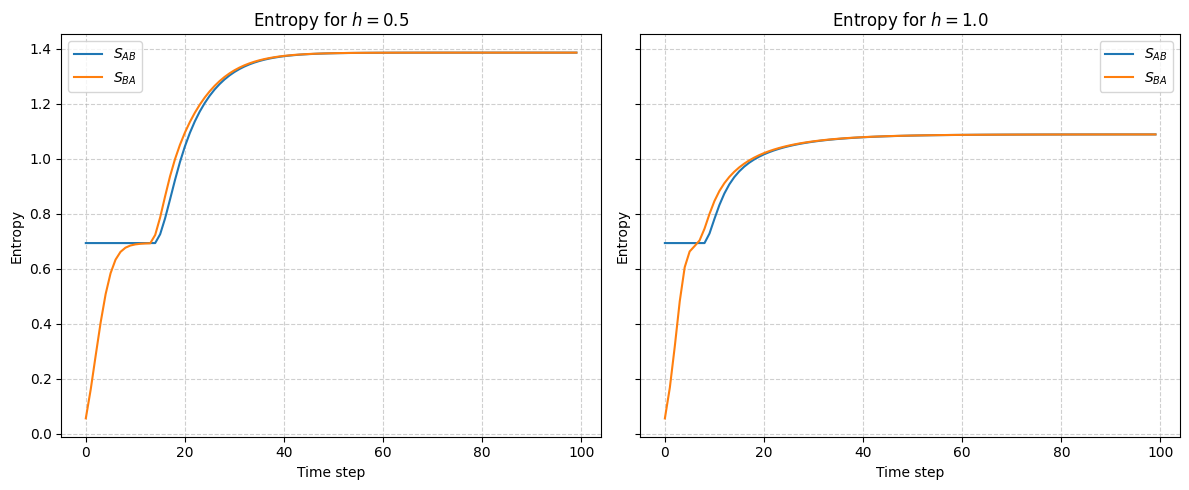

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, h in enumerate(h_list):
    ax = axes[i] # On sélectionne le subplot correspondant
    
    # Récupération des données
    data = out[str(h)]
    
    # Plot sur l'axe spécifique
    ax.plot(data["S_AB"], label=f"$S_{{AB}}$")
    ax.plot(data["S_BA"], label=f"$S_{{BA}}$")
    
    # Personnalisation de chaque sous-graphique
    ax.set_title(f"Entropy for $h = {h}$")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Entropy")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajuste automatiquement les espacements pour éviter les chevauchements
plt.show()

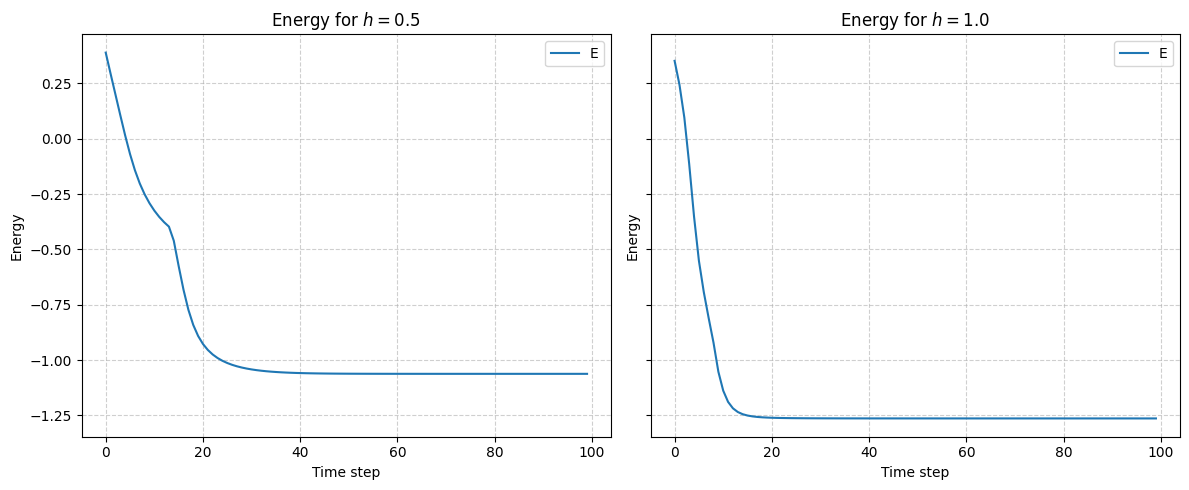

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, h in enumerate(h_list):
    ax = axes[i] # On sélectionne le subplot correspondant
    
    # Récupération des données
    data = out[str(h)]
    
    # Plot sur l'axe spécifique
    ax.plot(data["e"], label="E")
    
    # Personnalisation de chaque sous-graphique
    ax.set_title(f"Energy for $h = {h}$")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Energy")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajuste automatiquement les espacements pour éviter les chevauchements
plt.show()

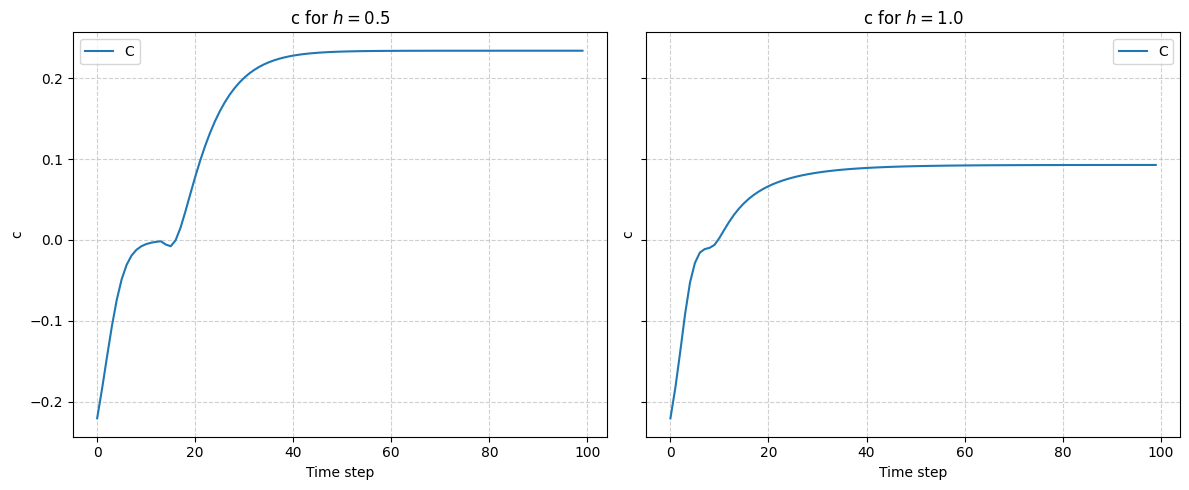

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, h in enumerate(h_list):
    ax = axes[i] # On sélectionne le subplot correspondant
    
    # Récupération des données
    data = out[str(h)]
    
    # Plot sur l'axe spécifique
    ax.plot(data["c"], label="C")
    
    # Personnalisation de chaque sous-graphique
    ax.set_title(f"c for $h = {h}$")
    ax.set_xlabel("Time step")
    ax.set_ylabel("c")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajuste automatiquement les espacements pour éviter les chevauchements
plt.show()

The known theoretical results are:
- for h = 1:
    - $E_0 \approx -1.27324J$
- for h = 1/2:
    - $E_0 \approx -1.11145J$

Let's compare our results with those of the td1 method, which uses the diagonalization of the H matrix.

In Td 1, exercise 2, we have:

In [100]:
def compute_H(L : int, h : float) : # calcul de l'Hamiltonien
  H = sparse.csr_matrix((2**L,2**L), dtype=complex)
  for j in range(L) :
    next_j = (j+1) % L # PBC L+1 = 0
    
    term_zz = np.array([[1]])
    term_x  = np.array([[1]])

    for site in range(L) :
      if site == j :
        op_zz = constants.Z
        op_x = constants.X
      elif site == next_j :
        op_zz = constants.Z
        op_x = constants.I
      else :
        op_zz = constants.I
        op_x = constants.I

      term_zz = np.kron(term_zz, op_zz)
      term_x = np.kron(term_x, op_x)

    H += term_zz + h * term_x
  return H

def SVD_method(v : np.array, L : int, ell : int) :
  dimHA = 2**ell
  dimHB = 2**(L-ell)
  vR = v.reshape((dimHA,dimHB))
  s = np.linalg.svdvals(vR) # calcul les singular value
  return s

L = 12 # on pose 12 car il faut un grand nombre mais pas trop car la méthode est gourmande en temps de calcul

E0_exact_diag, S_A_exact_diag = {}, {}
for h in h_list :
  H = compute_H(L,h)
  E0_exact_diag[str(h)], v0 = ground_state(H)

  ell = L//2
  s = SVD_method(v0, L, ell)
  S_A_exact_diag[str(h)] = measurements_entropy_SVD(s)

In [101]:
# on recupere les valeurs vers les quels on convergé la methode iTEBD
E0_iTEBD, S_AB_iTEBD = {}, {}
for h in h_list :
    E0_iTEBD[str(h)] = out[str(h)]["e"][-1]
    S_AB_iTEBD[str(h)] = out[str(h)]["S_AB"][-1]

# valeur théorique de E0
E0_theoric = {'0.5': -1.11145, '1.0': -1.27324}

for h in h_list :
    print(f"\nFor h = {h} :\n")
    print("iTEBD method :")
    print("E_0 :",E0_iTEBD[str(h)])
    print("error of E_0 :", np.abs(E0_iTEBD[str(h)] - E0_theoric[str(h)]))
    print("S_AB :", S_AB_iTEBD[str(h)])
    

    print("\nexact diagonalisation method :")
    print("E_0 :", E0_exact_diag[str(h)])
    print("error of E_0:", np.abs(E0_exact_diag[str(h)] - E0_theoric[str(h)]))
    print("S_AB :", S_A_exact_diag[str(h)])
    


For h = 0.5 :

iTEBD method :
E_0 : -1.062497247325493
error of E_0 : 0.04895275267450705
S_AB : 1.3862939324711414

exact diagonalisation method :
E_0 : -12.76256915102405
error of E_0: 11.65111915102405
S_AB : 0.6990136443953978

For h = 1.0 :

iTEBD method :
E_0 : -1.2639923768917791
error of E_0 : 0.009247623108220804
S_AB : 1.088561584828864

exact diagonalisation method :
E_0 : -15.32259515108078
error of E_0: 14.04935515108078
S_AB : 0.7022545114920649


We can see that the method using diagonalization is far too costly in terms of computing time for little result, unlike the iTEBD method, which is much more efficient.

### Output bonus :

In [102]:
Nt = 2000
dt = 0.2
h = 1

chi_max_list = np.linspace(10,50, 3, dtype=int)

S_AB = {}
for chi_max in chi_max_list:
  out = ite_bd_demo(h=h, delta=dt, nsteps=Nt, chi_max=chi_max, eps=1e-8)
  S_AB[str(chi_max)] = out["S_AB"]
  print(f"chi_max = {chi_max} finish")

chi_max = 10 finish
chi_max = 30 finish
chi_max = 50 finish


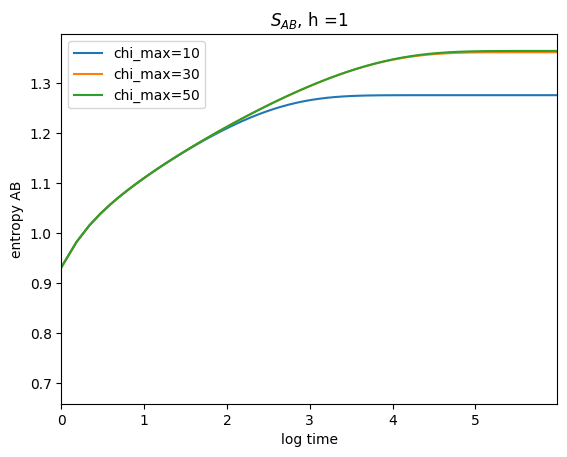

In [103]:
t = np.linspace(constants.epsilon, Nt*dt, Nt)
logt = np.log(t)

plt.figure()
for chi_max in chi_max_list:
  plt.plot(logt, S_AB[str(chi_max)], label="chi_max="+str(chi_max))
plt.xlim(0, np.max(logt))
plt.title("$S_{AB}$, h ="+str(h))
plt.xlabel("log time")
plt.ylabel("entropy AB")
plt.legend()
plt.show()

---

# References

- Jacopo DE-NARDIS's course on Quasi-exact numerical method for quantum system (Master 2)
- Numpy https://numpy.org/doc/stable/
- Scipy https://docs.scipy.org/doc/scipy/
- Latex Tiks https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts
